# Analiz Modeli — Kriz Kontrafaktüeli

> ## ⚠️ Bu notebook `crisis_cf_v1`'i anlatır — birincil alet artık `crisis_cf_v5`
>
> v1 iki dönemde sistematik sapma taşıyor (Ara 2021–Mar 2022 ve Eki 2022–Mar 2023).
> Sebebi bulundu ve giderildi: modele beslenen gaz maliyeti yanlış seriden geliyordu.
> **Yeni analizlerde `model_name='crisis_cf_v5'` kullan.**
>
> Bu notebook yine de geçerli ve okunmalı: aletin nasıl kurulduğunu, örneklem-dışı
> şemayı, boş bandı ve varyant çatalını anlatır — hepsi v5'te de aynen geçerli.
> Aşağıdaki v1 rakamları (özellikle §5 İran fazları ve §7 anormal gün listesi)
> **sapmalıdır**; düzeltilmiş hâlleri `03_gas_tariff_discovery.ipynb` §7'de.

**Konum:** `experiments/notebooks/05_crisis_analysis/01_counterfactual_model.ipynb`
**Tarih:** 18 Ağustos 2026
**Kaynak:** `CRISIS_ANALYSIS_PLAN.md` §3.4 ve §8 adım 6 · kod: `src/crisis/analysis_model.py`
**Üreten:** `python scripts/build_analysis_model.py --variant both --write`

## Soru

Bir kriz sırasında fiyat yükseldi — bunun ne kadarı olay, ne kadarı zaten olacak olan?
"İran gazı kesildi, fiyat tavana vurdu" tek başına bir şey kanıtlamıyor: o hafta hava da
serinin en soğuğuydu, talep de yüksekti.

## Yöntem

Fundamentallerden fiyat tahmin eden bir model kurulur; girdisi o saatin **gerçekleşen**
verisi (kaç MW gaz yakıldı, hava kaç derece, hidro ne durumda, yakıt kaça). Model
"bu koşullarda fiyat şu olmalı" der. Gerçek fiyat ile arasındaki fark **kalıntı**:

    kalıntı = gerçek − kontrafaktüel = "fundamentallerle açıklanamayan fiyat"

Hava ve yakıt etkisi modelin içinde olduğu için kalıntıdan arınmıştır.

## Canlı modelden üç bilinçli ayrım

| | Canlı (`lgb_lag0_v2`) | Analiz modeli |
|---|---|---|
| Eğitim başlangıcı | 2023-01-01 | **2021-01-01** |
| Tavandaki saatler | eğitimde | **eğitimde DEĞİL** (tahmin hepsine üretilir) |
| O saatin arz kırılımı | görülemez (pre-forecast) | **görülür** (lag0 gerçekleşen) |

Üçüncüsü ölçünün tanımını belirler: ölçtüğümüz **"açıklanamayan"**, "sürpriz" değil.
Soru "gaz düşüşü yükselişi açıklıyor mu" olduğu için modelin gaz düşüşünü görmesi gerekir.

## Kalıcı kısıt

Model sansürsüz saatlerde eğitildiği için tavan üstü fiyat hiç görmedi; ağaç modeli
eğitimde gördüğü maksimumun üstünü tahmin edemez. **Tavandaki saatlerde kontrafaktüel
de kalıntı da ALT SINIRDIR** (`is_lower_bound`). Yöntemin düzeltilebilir bir hatası
değil, doğasında olan kısıt.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parents[2]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import text
from db.connection import get_db_engine

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4.5)
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)

engine = get_db_engine()

# Analiz modelinin birincil sürümü. crisis_cf_v2/v3/v4 karşılaştırma içindir,
# analizde kullanma (gerekçe: 02_model_bias_investigation.ipynb §7).
VARIANT = 'fundamental'
MODEL   = 'crisis_cf_v1'

def cf(model=None, variant=None, where=''):
    """gold.crisis_counterfactual okuma yardımcısı — saat indeksli, tz-aware."""
    q = text(f"""
        SELECT ts, actual_usd, counterfactual_usd, residual_usd, at_cap, is_lower_bound, fold_id
        FROM gold.crisis_counterfactual
        WHERE variant = :v AND model_name = :m {where}
        ORDER BY ts
    """)
    d = pd.read_sql(q, engine, params={'v': variant or VARIANT, 'm': model or MODEL})
    d['ts'] = pd.to_datetime(d['ts'], utc=True).dt.tz_convert('Europe/Istanbul')
    for c in ['actual_usd', 'counterfactual_usd', 'residual_usd']:
        d[c] = d[c].astype(float)
    return d.set_index('ts')

print('bağlantı hazır')

bağlantı hazır


## 1. Kapsam ve sansür

Kontrafaktüel her saat için üretildi, ama modelin eğitimi sadece tavana değmemiş
saatlerde yapıldı. Önce ikisinin oranına bakalım.

kapsam : 2021-01-08 00:00:00+03:00 → 2026-08-18 07:00:00+03:00
saat   : 49064 | blok: 74
tavanda: 7613 (%15.5)


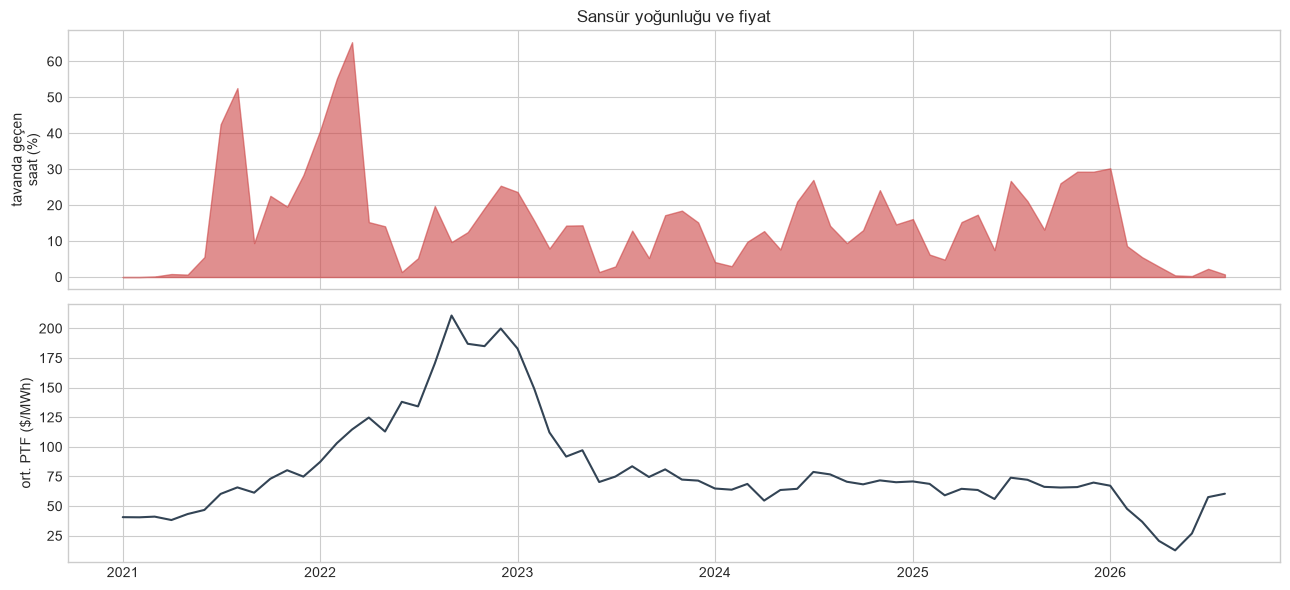

In [2]:
d = cf()
print('kapsam :', d.index.min(), '→', d.index.max())
print('saat   :', len(d), '| blok:', d.fold_id.nunique())
print('tavanda: %d (%%%.1f)' % (d.at_cap.sum(), 100 * d.at_cap.mean()))

aylik = d.resample('MS').agg(sansur=('at_cap', 'mean'), fiyat=('actual_usd', 'mean'))
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax[0].fill_between(aylik.index, 100 * aylik.sansur, color='#c44', alpha=.6)
ax[0].set_ylabel('tavanda geçen\nsaat (%)'); ax[0].set_title('Sansür yoğunluğu ve fiyat')
ax[1].plot(aylik.index, aylik.fiyat, color='#345')
ax[1].set_ylabel('ort. PTF ($/MWh)')
plt.tight_layout(); plt.show()

### 📌 Bölüm 1 Analiz Notları

- Saatlerin **%15,5'i tavanda**. 2022 Mart'ta bu oran %65'e çıkıyor — incelemek
  istediğimiz krizin tam ortasında fiyat fiziksel olarak yükselemiyor.
- Bu yüzden klasik event study burada yanıltıcıdır: şok sistematik olarak
  olduğundan küçük ölçülür. Kalıntı yaklaşımı bunu `is_lower_bound` ile işaretler.

## 2. Örneklem-dışı doğruluk

Her blok, o bloğu hiç görmemiş bir model tarafından tahmin edildi (28 günlük bloklar,
iki yanında 8 günlük tampon — 168 saatlik lag'ler sızmasın diye).

**Neden ileri yönlü walk-forward değil:** genişleyen pencere Ocak 2022 için sadece 2021'i
görürdü ve ağaç modeli eğitimde gördüğü maksimumun üstünü tahmin edemez — serinin ilk
büyük şoku otomatik olarak "açıklanamayan" çıkardı, bu bir yöntem artefaktı olurdu.

Doğruluk yalnızca **sansürsüz** saatlerde ölçülür; model orada eğitildi.

In [3]:
unc = d[~d.at_cap]

print('MAE   : $%6.2f' % unc.residual_usd.abs().mean())
print('BIAS  : $%+6.2f' % unc.residual_usd.mean())
print('Medyan: $%+6.2f' % unc.residual_usd.median())

yillik = unc.groupby(unc.index.year).agg(
    n=('residual_usd', 'size'),
    ort_fiyat=('actual_usd', 'mean'),
    MAE=('residual_usd', lambda s: s.abs().mean()),
    BIAS=('residual_usd', 'mean'),
)
display(yillik.round(2))

MAE   : $  9.96
BIAS  : $ +0.49
Medyan: $ -0.27


,n,ort_fiyat,MAE,BIAS
ts,,,,
2021,7245,50.93,5.91,-1.46
2022,6699,142.76,20.77,1.91
2023,7670,90.78,12.13,4.52
2024,7604,65.17,6.83,-0.14
2025,7195,62.75,6.30,-0.42
2026,5038,37.68,8.05,-2.44


## 3. Kalıntının boş dağılımı — "anormal" ne demek

Bir olayın kalıntısı bu bandın dışına çıkmıyorsa ona "anormal" denemez. Eşik gözle
değil bu dağılımla belirlenir.

p1=$-37.7  p5=$-21.1  p25=$-6.6  p50=$-0.3  p75=$+5.8  p95=$+26.6  p99=$+50.3


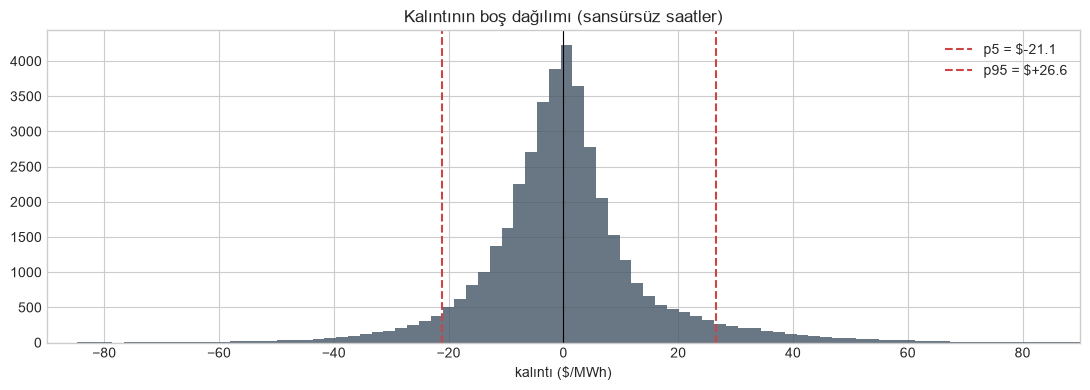

In [4]:
q = unc.residual_usd.quantile([.01, .05, .25, .5, .75, .95, .99])
print('  '.join(f'p{int(k*100)}=${v:+.1f}' for k, v in q.items()))

fig, ax = plt.subplots(figsize=(11, 4))
ax.hist(unc.residual_usd, bins=140, color='#456', alpha=.8)
for p, c in [(.05, '#c44'), (.95, '#c44')]:
    ax.axvline(unc.residual_usd.quantile(p), color=c, ls='--',
               label=f'p{int(p*100)} = ${unc.residual_usd.quantile(p):+.1f}')
ax.axvline(0, color='k', lw=.8)
ax.set_xlim(-90, 90); ax.set_xlabel('kalıntı ($/MWh)'); ax.legend()
ax.set_title('Kalıntının boş dağılımı (sansürsüz saatler)')
plt.tight_layout(); plt.show()

### 📌 Bölüm 3 Analiz Notları

- Band: **p5 = −$21,1 · p95 = +$26,6**. Normal zamanlarda model $6-8 yanılıyor,
  yani $27'lik bir sapma gürültü değil.
- Bu band adım 7'nin (etki analizi) eşiğidir: bir olay penceresinde bandın üstünde
  geçen saat oranı %5'i belirgin aşmıyorsa "anormallik" iddia edilemez.

## 4. Ölçülmüş karar — fiyat türevli feature'lar neden dışarıda

İki varyant koşuldu:

- `fundamental` — fiyattan türeyen hiçbir şey yok (mcp lag/rolling, rejim bayrakları, SMF lag)
- `autoregressive` — canlı modelin feature seti + lag0 blok

Nokta doğruluğunda `autoregressive` biraz daha iyi ($9,17 vs $9,96 MAE). Ama olay
ölçümünde kullanılamaz, ve sebebi aşağıdaki grafikte doğrudan görünüyor.

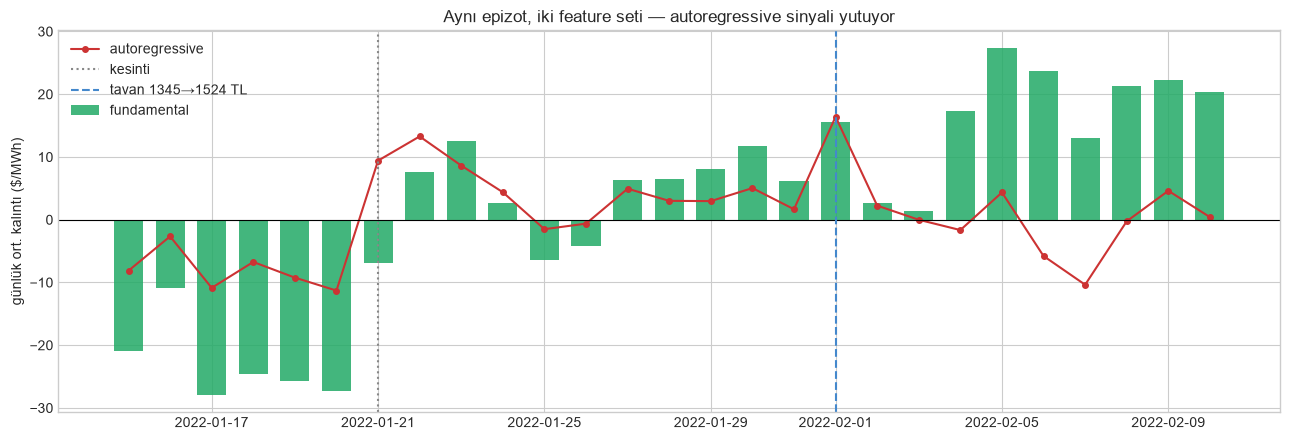

pencere ortalaması  fundamental: $+2.7   autoregressive: $+0.5


In [5]:
# Yarı açık aralık: scripts/build_analysis_model.py ile aynı tanım olsun diye
# bitiş günü dahil edilmiyor (pandas .loc dilimi bitişi kapsar, bu +$0,7 fark yaratıyordu).
IRAN_BAS, IRAN_BIT = '2022-01-15', '2022-02-11'
def iran_penceresi(varyant):
    x = cf(variant=varyant)
    return x[(x.index >= IRAN_BAS) & (x.index < IRAN_BIT)]

f_ = iran_penceresi('fundamental')
a_ = iran_penceresi('autoregressive')

gf = f_.resample('D').agg(kalinti=('residual_usd', 'mean'), tavan=('at_cap', 'sum'))
ga = a_.resample('D').agg(kalinti=('residual_usd', 'mean'))

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.bar(gf.index, gf.kalinti, width=.7, color='#2a6', alpha=.85, label='fundamental')
ax.plot(ga.index, ga.kalinti, 'o-', color='#c33', ms=4, label='autoregressive')
ax.axhline(0, color='k', lw=.8)
ax.axvline(pd.Timestamp('2022-01-21', tz='Europe/Istanbul'), color='#888', ls=':', label='kesinti')
ax.axvline(pd.Timestamp('2022-02-01', tz='Europe/Istanbul'), color='#48c', ls='--', label='tavan 1345→1524 TL')
ax.set_ylabel('günlük ort. kalıntı ($/MWh)'); ax.legend()
ax.set_title('Aynı epizot, iki feature seti — autoregressive sinyali yutuyor')
plt.tight_layout(); plt.show()

print('pencere ortalaması  fundamental: $%+.1f   autoregressive: $%+.1f'
      % (f_.residual_usd.mean(), a_.residual_usd.mean()))

### 📌 Bölüm 4 Analiz Notları

- `autoregressive` varyantta kalıntı ilk günden sonra **sıfıra çöküyor**: `mcp_usd_lag_24`
  modele dünkü şok fiyatını veriyor, model şoku "tahmin ediyor". 5 Şubat'ta fundamental
  +$27,4 derken o +$4,3 diyor.
- 10 günlük bir epizodun 9 günü görünmez olurdu. **Olay ölçümünde `fundamental` kullanılır.**
- Bedeli sadece $0,79 MAE — bu takas ucuz.
- Aynı hata yakıt maliyeti geçmişi eklenince de tekrarlanıyor; bkz.
  `02_model_bias_investigation.ipynb` §7.

## 5. İran gaz kesintisi — tek ortalama yanıltıcı

Pencere ortalaması +$2,7. Ama içinde üç ayrı rejim var ve ortalama bunları birbirine
karıştırıyor. Faz sınırları olaydan bağımsız belirlendi: kesinti tarihi (21 Ocak,
haber arşivi) ve tavanın yükseltilme tarihi (1 Şubat, `silver.price_cap_official`).

,n,gercek,kontrafaktuel,kalinti,tavan_pct
faz,,,,,
Kesinti öncesi (15-20 Oca),144,81.8,104.7,-22.9,13.2
Kesinti + kısıntı (21-31 Oca),264,95.7,91.7,4.0,85.6
Tavan yükseldikten sonra (1-10 Şub),240,103.2,86.8,16.5,62.9


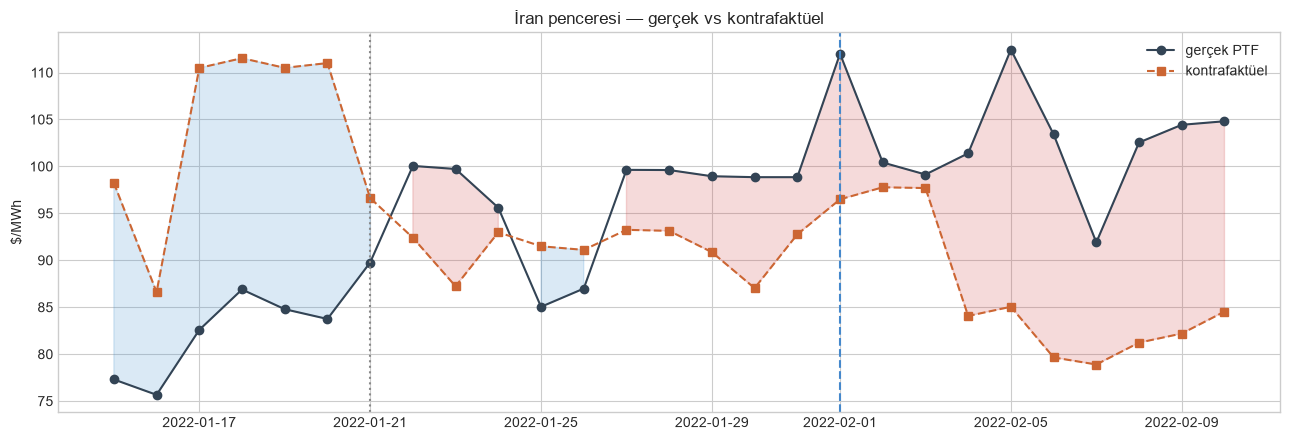

In [6]:
w = cf(); w = w[(w.index >= '2022-01-15') & (w.index < '2022-02-11')]
fazlar = {
    'Kesinti öncesi (15-20 Oca)':      ('2022-01-15', '2022-01-21'),
    'Kesinti + kısıntı (21-31 Oca)':   ('2022-01-21', '2022-02-01'),
    'Tavan yükseldikten sonra (1-10 Şub)': ('2022-02-01', '2022-02-11'),
}
rows = []
for ad, (a, b) in fazlar.items():
    s = w[(w.index >= a) & (w.index < b)]
    rows.append(dict(faz=ad, n=len(s), gercek=s.actual_usd.mean(),
                     kontrafaktuel=s.counterfactual_usd.mean(),
                     kalinti=s.residual_usd.mean(), tavan_pct=100 * s.at_cap.mean()))
display(pd.DataFrame(rows).set_index('faz').round(1))

g = w.resample('D').agg(gercek=('actual_usd', 'mean'), kontraf=('counterfactual_usd', 'mean'),
                        tavan=('at_cap', 'sum'))
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(g.index, g.gercek, 'o-', color='#345', label='gerçek PTF')
ax.plot(g.index, g.kontraf, 's--', color='#c63', label='kontrafaktüel')
ax.fill_between(g.index, g.gercek, g.kontraf, where=g.gercek >= g.kontraf, color='#c33', alpha=.18)
ax.fill_between(g.index, g.gercek, g.kontraf, where=g.gercek < g.kontraf, color='#38c', alpha=.18)
ax.axvline(pd.Timestamp('2022-01-21', tz='Europe/Istanbul'), color='#888', ls=':')
ax.axvline(pd.Timestamp('2022-02-01', tz='Europe/Istanbul'), color='#48c', ls='--')
ax.set_ylabel('$/MWh'); ax.legend(); ax.set_title('İran penceresi — gerçek vs kontrafaktüel')
plt.tight_layout(); plt.show()

### 📌 Bölüm 5 Analiz Notları

| Faz | gerçek | kontrafaktüel | kalıntı | tavanda |
|---|---|---|---|---|
| Kesinti öncesi | $81,7 | $104,5 | **−$22,8** | %13 |
| Kesinti + kısıntı | $96,1 | $91,7 | **+$4,4** | %87 |
| Tavan yükseldikten sonra | $103,1 | $86,8 | **+$16,4** | %62 |

- **Kesinti sırasında kalıntı sadece +$4,4 görünüyor** ama saatlerin %87'si tavanda —
  bu eksik ölçüm, gerçek değer daha büyük.
- **1 Şubat'ta tavan 1.345 → 1.524 TL'ye çıkarılınca kalıntı aynı gün +$16'ya fırlıyor.**
  Yani Ocak boyunca gerçek fiyat tavanın epey üstündeymiş. "Tavandaki kalıntı alt
  sınırdır" şerhi burada teorik değil, gözlemlenmiş durumda.
- **Kesinti öncesi −$22,8 bir model sapmasıdır, bulgu değil.** Sebebi
  `02_model_bias_investigation.ipynb`'de: BOTAŞ o dönemde elektrik üretim gazını
  piyasa fiyatının %45 altında satıyordu, model maliyeti olduğundan yüksek sandı.
  **Bu dönemdeki ölçümler bu sapma düzeltilmeden kullanılmamalı.**

## 6. Yıllar arası aynı takvim penceresi

Mevsimsellik sabit tutulmadan "2022 anormaldi" denemez. `CRISIS_CASE_IRAN_2022.md` §6
aynı karşılaştırmayı ham fiyatla yapmıştı; buradaki fark, fiyatın yerine **kalıntının**
karşılaştırılması — hava, talep ve yakıt maliyeti zaten arındırılmış.

Aynı çıktıyı komut satırından almak için:
`python scripts/crisis_case_report.py --window 01-15 02-10`

In [7]:
lo, hi = unc.residual_usd.quantile([.05, .95])
rows = []
for yil in range(2021, 2027):
    s = d[(d.index >= f'{yil}-01-15') & (d.index < f'{yil}-02-11')]
    if s.empty:
        continue
    rows.append(dict(yil=yil, saat=len(s), gercek=s.actual_usd.mean(),
                     kontraf=s.counterfactual_usd.mean(), kalinti=s.residual_usd.mean(),
                     tavan_pct=100 * s.at_cap.mean(),
                     band_ustu_pct=100 * (s.residual_usd > hi).mean()))
karsilastirma = pd.DataFrame(rows).set_index('yil')

# mekanizma sütunları
mek = pd.read_sql(text("""
    SELECT date_trunc('year', k.ts) yil,
           AVG(k.natural_gas_mw) gaz_mw,
           AVG(k.dammed_hydro_mw + k.river_hydro_mw) hidro_mw,
           AVG(w.turkey_weighted_temperature_c) sicaklik
    FROM raw_kgup_hourly k LEFT JOIN raw_weather_hourly w ON k.ts = w.ts
    WHERE to_char(k.ts, 'MM-DD') BETWEEN '01-15' AND '02-10'
    GROUP BY 1 ORDER BY 1
"""), engine)
mek['yil'] = pd.to_datetime(mek.yil, utc=True).dt.year
karsilastirma = karsilastirma.join(mek.set_index('yil'))
display(karsilastirma.round(1))
print(f'boş beklenti: band üstü %5 (p95 = ${hi:+.1f})')

,saat,gercek,kontraf,kalinti,tavan_pct,band_ustu_pct,gaz_mw,hidro_mw,sicaklik
yil,,,,,,,,,
2021,648,40.3,41.2,-0.9,0.0,0.0,8428.7,5221.5,3.1
2022,648,95.4,92.8,2.7,61.1,8.5,8562.6,3236.5,6.1
2023,648,170.5,155.2,15.3,20.8,35.3,3972.2,11140.0,7.3
2024,648,66.1,64.4,1.6,3.1,0.6,10636.6,5771.6,6.8
2025,648,70.2,71.5,-1.3,13.6,0.0,8685.9,7377.5,7.5
2026,648,64.7,66.6,-1.8,24.1,0.0,NaN,NaN,NaN


boş beklenti: band üstü %5 (p95 = $+26.6)


### 📌 Bölüm 6 Analiz Notları

- **2024, gazı 2022'den %53 daha düşük olmasına rağmen tamamen normal:** band üstü saat
  oranı %0,6 (boş beklenti %5). Fundamentaller o pencerede fiyatın tamamını açıklıyor.
- Farkı yapan hidro: 11.140 MW, 2022'nin iki katından fazla; üstüne 4,2 °C daha sıcak.
  Yani **"gaz düşerse fiyat patlar" tek başına yanlış** — vaka dokümanının sonucu,
  bu kez hava/yakıttan arındırılmış bir ölçüyle doğrulandı.
- 2022 band üstü %8,5 **ve saatlerinin %61'i sansürlü** — gerçek anormallik bundan büyük.
- 2023 bu pencerede en yüksek görünüyor (%35,3) ama bu bir olay değil, model sapması —
  bkz. `02_model_bias_investigation.ipynb`.

## 7. En anormal günler — adım 7'nin girdisi

Planın §5'indeki betimsel çıktının ham malzemesi: *"2021'den bu yana en büyük N anormal
günün kaçının tanımlı bir sebebi var, hangi kanaldan?"*

**Uyarı:** aşağıdaki liste henüz ham. İki dönem bilinen sapma taşıyor (Oca-Şub 2022 ve
Eki 2022 – Mar 2023) ve liste o dönemlere doğru eğrilmiş durumda. Sapma düzeltilmeden
haber eşleştirmesine geçilmemeli.

--- en büyük 20 açıklanamayan gün (↑) ---


,gercek,kontraf,kalinti,tavan,alt_sinir
ts,,,,,
2023-02-14 00:00:00+03:00,169.3,125.4,43.9,7,True
2023-02-24 00:00:00+03:00,164.5,120.9,43.6,7,True
2022-11-24 00:00:00+03:00,210.0,166.6,43.4,11,True
2022-12-21 00:00:00+03:00,224.7,181.9,42.9,15,True
2022-12-22 00:00:00+03:00,234.6,193.4,41.1,14,True
2023-02-22 00:00:00+03:00,163.9,123.4,40.5,6,True
2023-02-23 00:00:00+03:00,162.4,122.1,40.2,4,True
2023-02-16 00:00:00+03:00,166.7,126.8,39.9,6,True
2023-01-30 00:00:00+03:00,205.4,166.4,38.9,15,True


† alt_sinir=True olan günlerde kalıntı ALT SINIRDIR (model tavan üstü tahmin edemez)


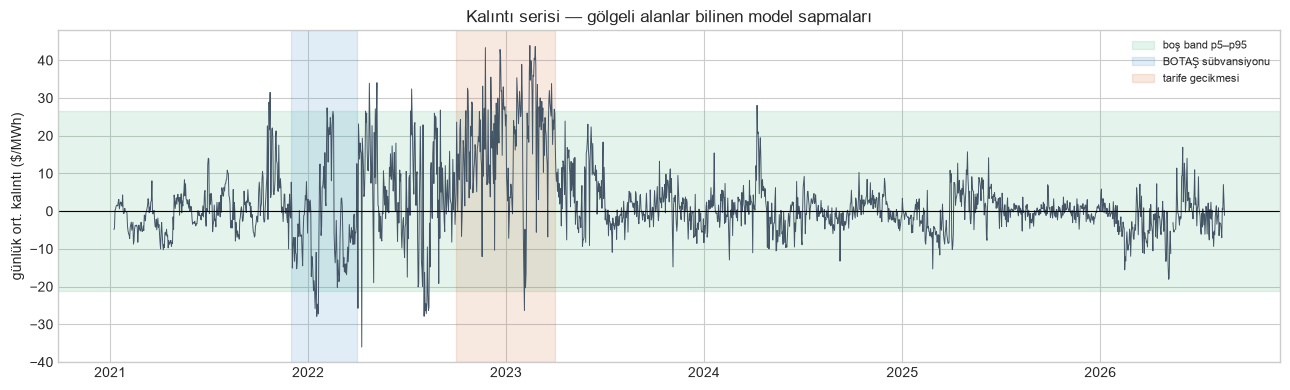

In [8]:
gunluk = d.resample('D').agg(
    gercek=('actual_usd', 'mean'), kontraf=('counterfactual_usd', 'mean'),
    kalinti=('residual_usd', 'mean'), tavan=('at_cap', 'sum'),
)
gunluk['alt_sinir'] = gunluk.tavan > 0

print('--- en büyük 20 açıklanamayan gün (↑) ---')
display(gunluk.sort_values('kalinti', ascending=False).head(20).round(1))
print('† alt_sinir=True olan günlerde kalıntı ALT SINIRDIR (model tavan üstü tahmin edemez)')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(gunluk.index, gunluk.kalinti, lw=.7, color='#456')
ax.axhline(0, color='k', lw=.8)
ax.axhspan(lo, hi, color='#2a6', alpha=.12, label=f'boş band p5–p95')
for a, b, c, t in [('2021-12-01', '2022-04-01', '#38c', 'BOTAŞ sübvansiyonu'),
                   ('2022-10-01', '2023-04-01', '#c63', 'tarife gecikmesi')]:
    ax.axvspan(pd.Timestamp(a, tz='Europe/Istanbul'), pd.Timestamp(b, tz='Europe/Istanbul'),
               color=c, alpha=.15, label=t)
ax.set_ylabel('günlük ort. kalıntı ($/MWh)'); ax.legend(loc='upper right', fontsize=8)
ax.set_title('Kalıntı serisi — gölgeli alanlar bilinen model sapmaları')
plt.tight_layout(); plt.show()

### 📌 Bölüm 7 Analiz Notları

- Listenin tepesi Şubat 2023'te yoğunlaşıyor (13/20 gün). Bu **olay değil, sapma** —
  o dönem model gaz maliyetini olduğundan düşük görüyor.
- Gölgeli iki alan düzeltilene kadar bu liste adım 7'nin girdisi olamaz. Sıradaki iş
  `silver.gas_tariff_electricity` serisini kurup v5'i koşmak; bkz.
  `03_gas_tariff_discovery.ipynb`.